In [1]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

In [2]:
ruta_al_archivo = 'prueba.mp3'

# Cargar el archivo MP3
y, sr = librosa.load(ruta_al_archivo)

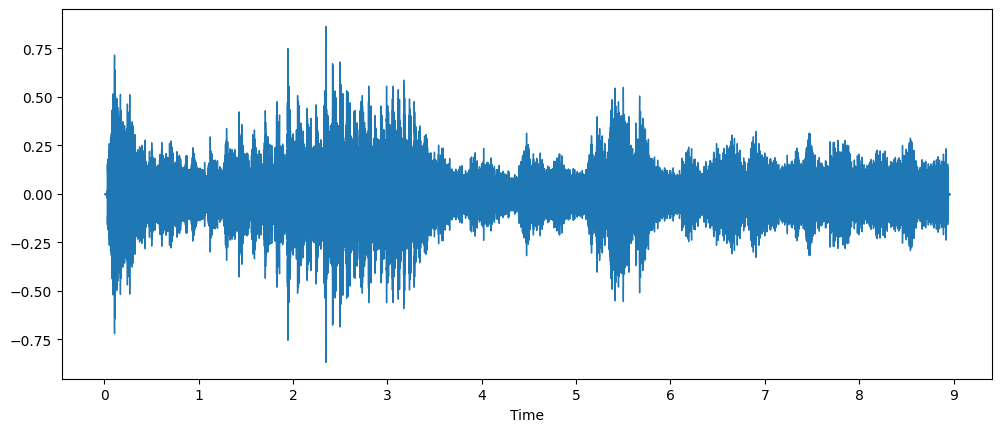

In [3]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(y, sr=sr)

Esto traza la amplitud de la señal en el eje y y el tiempo a lo largo del eje x. En otras palabras, cada punto corresponde a un único valor de muestra que se tomó cuando se muestreó este sonido. También tenga en cuenta que librosa ya devuelve el audio como valores de punto flotante y que los valores de amplitud están efectivamente dentro del rango [-1.0, 1.0].

Visualizar el audio junto con escucharlo puede ser una herramienta útil para comprender los datos con los que está trabajando. Puedes ver la forma de la señal, observar patrones, aprender a detectar ruido o distorsión. Si preprocesa los datos de alguna manera, como normalización, remuestreo o filtrado, puede confirmar visualmente que los pasos de preprocesamiento se han aplicado según lo esperado. Después de entrenar un modelo, también puede visualizar muestras donde ocurren errores (por ejemplo, en la tarea de clasificación de audio) para depurar el problema.

## El espectro de frecuencia
Otra forma de visualizar datos de audio es trazar el espectro de frecuencia de una señal de audio, también conocido como representación en el dominio de la frecuencia . El espectro se calcula mediante la transformada discreta de Fourier o DFT. Describe las frecuencias individuales que componen la señal y su intensidad.

Tracemos el espectro de frecuencia para el mismo sonido de trompeta tomando el DFT usando rfft()la función de numpy. Si bien es posible trazar el espectro de todo el sonido, es más útil observar una región pequeña. Aquí tomaremos el DFT de las primeras 4096 muestras, que es aproximadamente la duración de la primera nota que se toca:

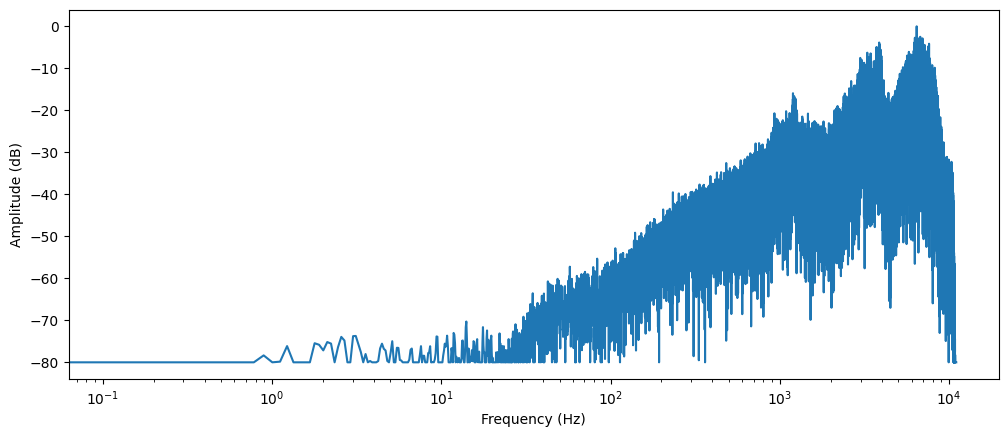

In [6]:
import numpy as np

dft_input = y

# calculate the DFT
window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)

# get the amplitude spectrum in decibels
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

# get the frequency bins
frequency = librosa.fft_frequencies(sr=sr, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")

Esto traza la fuerza de los distintos componentes de frecuencia que están presentes en este segmento de audio. Los valores de frecuencia están en el eje x, generalmente representados en una escala logarítmica, mientras que sus amplitudes están en el eje y.

El espectro de frecuencia que trazamos muestra varios picos. Estos picos corresponden a los armónicos de la nota que se está tocando, siendo los armónicos más altos los más silenciosos. Dado que el primer pico está alrededor de 620 Hz, este es el espectro de frecuencia de una nota E♭.

La salida de la DFT es una matriz de números complejos, formada por componentes reales e imaginarios. Al tomar la magnitud np.abs(dft)se extrae la información de amplitud del espectrograma. El ángulo entre los componentes real e imaginario proporciona el llamado espectro de fase, pero esto a menudo se descarta en las aplicaciones de aprendizaje automático.

Solías librosa.amplitude_to_db()convertir los valores de amplitud a la escala de decibelios, lo que facilita ver los detalles más finos del espectro. A veces la gente utiliza el espectro de potencia , que mide la energía en lugar de la amplitud; esto es simplemente un espectro con los valores de amplitud al cuadrado.

El espectro de frecuencia de una señal de audio contiene exactamente la misma información que su forma de onda; son simplemente dos formas diferentes de ver los mismos datos (aquí, las primeras 4096 muestras del sonido de la trompeta). Mientras que la forma de onda traza la amplitud de la señal de audio a lo largo del tiempo, el espectro visualiza las amplitudes de las frecuencias individuales en un punto fijo en el tiempo.

## Espectrograma
¿Qué pasa si queremos ver cómo cambian las frecuencias en una señal de audio? La trompeta toca varias notas y todas tienen frecuencias diferentes. El problema es que el espectro sólo muestra una instantánea congelada de las frecuencias en un instante determinado. La solución es tomar múltiples DFT, cada una de las cuales cubra solo una pequeña porción de tiempo, y apilar los espectros resultantes en un espectrograma .

Un espectrograma traza el contenido de frecuencia de una señal de audio a medida que cambia con el tiempo. Le permite ver el tiempo, la frecuencia y la amplitud, todo en un solo gráfico. El algoritmo que realiza este cálculo es el STFT o Transformada de Fourier de Tiempo Corto.

El espectrograma es una de las herramientas de audio más informativas disponibles para usted. Por ejemplo, cuando trabaja con una grabación musical, puede ver los distintos instrumentos y pistas vocales y cómo contribuyen al sonido general. En el habla, puedes identificar diferentes sonidos vocálicos, ya que cada vocal se caracteriza por frecuencias particulares.

Tracemos un espectrograma para el mismo sonido de trompeta, usando las funciones stft()y de librosa specshow():

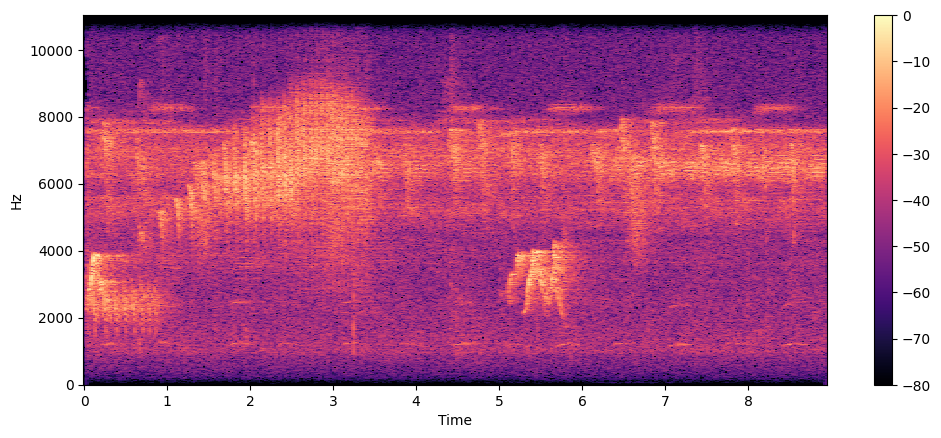

In [9]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()

En este gráfico, el eje x representa el tiempo como en la visualización de forma de onda, pero ahora el eje y representa la frecuencia en Hz. La intensidad del color proporciona la amplitud o potencia del componente de frecuencia en cada momento, medida en decibelios (dB).

El espectrograma se crea tomando segmentos cortos de la señal de audio, que generalmente duran unos pocos milisegundos, y calculando la transformada de Fourier discreta de cada segmento para obtener su espectro de frecuencia. Luego, los espectros resultantes se apilan en el eje del tiempo para crear el espectrograma. Cada corte vertical en esta imagen corresponde a un único espectro de frecuencia, visto desde arriba. De forma predeterminada, librosa.stft()divide la señal de audio en segmentos de 2048 muestras, lo que ofrece un buen equilibrio entre resolución de frecuencia y resolución de tiempo.

Dado que el espectrograma y la forma de onda son vistas diferentes de los mismos datos, es posible volver a convertir el espectrograma a la forma de onda original utilizando el STFT inverso. Sin embargo, esto requiere la información de fase además de la información de amplitud. Si el espectrograma fue generado por un modelo de aprendizaje automático, normalmente solo genera las amplitudes. En ese caso, podemos usar un algoritmo de reconstrucción de fase como el algoritmo clásico de Griffin-Lim, o usar una red neuronal llamada vocoder, para reconstruir una forma de onda a partir del espectrograma.

Los espectrogramas no se utilizan sólo para visualización. Muchos modelos de aprendizaje automático tomarán espectrogramas como entrada (en lugar de formas de onda) y producirán espectrogramas como salida.

Ahora que sabemos qué es un espectrograma y cómo se elabora, echemos un vistazo a una variante ampliamente utilizada para el procesamiento del habla: el espectrograma mel.

## Espectrograma mel
Un espectrograma mel es una variación del espectrograma que se usa comúnmente en tareas de procesamiento del habla y aprendizaje automático. Es similar a un espectrograma en que muestra el contenido de frecuencia de una señal de audio a lo largo del tiempo, pero en un eje de frecuencia diferente.

En un espectrograma estándar, el eje de frecuencia es lineal y se mide en hercios (Hz). Sin embargo, el sistema auditivo humano es más sensible a los cambios en las frecuencias más bajas que en las más altas, y esta sensibilidad disminuye logarítmicamente a medida que aumenta la frecuencia. La escala mel es una escala de percepción que se aproxima a la respuesta de frecuencia no lineal del oído humano.

Para crear un espectrograma mel, se utiliza el STFT como antes, dividiendo el audio en segmentos cortos para obtener una secuencia de espectros de frecuencia. Además, cada espectro se envía a través de un conjunto de filtros, el llamado banco de filtros mel, para transformar las frecuencias a la escala mel.

Veamos cómo podemos trazar un espectrograma mel usando melspectrogram()la función de librosa, que realiza todos esos pasos por nosotros:

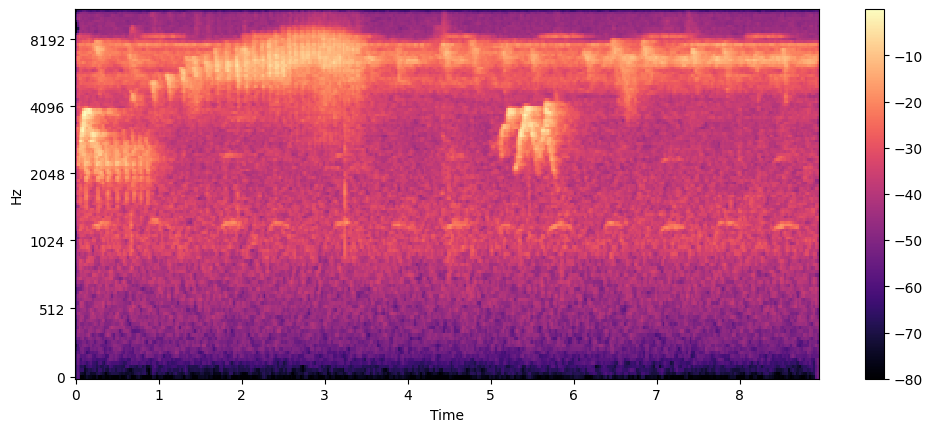

In [11]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sr)
plt.colorbar()

En el ejemplo anterior, n_melsrepresenta el número de bandas mel que se generarán. Las bandas mel definen un conjunto de rangos de frecuencia que dividen el espectro en componentes perceptivamente significativos, utilizando un conjunto de filtros cuya forma y espaciado se eligen para imitar la forma en que el oído humano responde a diferentes frecuencias. Los valores comunes n_melsson 40 u 80. fmax Indica la frecuencia más alta (en Hz) que nos interesa.

Al igual que con un espectrograma normal, es una práctica común expresar la fuerza de los componentes de la frecuencia mel en decibelios. Esto se conoce comúnmente como espectrograma log-mel , porque la conversión a decibelios implica una operación logarítmica. El ejemplo anterior utilizado librosa.power_to_db()crea librosa.feature.melspectrogram()un espectrograma de potencia.

Crear un espectrograma mel es una operación con pérdidas ya que implica filtrar la señal. Convertir un espectrograma mel nuevamente en una forma de onda es más difícil que hacerlo con un espectrograma normal, ya que requiere estimar las frecuencias que se descartaron. Es por eso que se necesitan modelos de aprendizaje automático como el codificador de voz HiFiGAN para producir una forma de onda a partir de un espectrograma mel.

En comparación con un espectrograma estándar, un espectrograma mel puede capturar características más significativas de la señal de audio para la percepción humana, lo que lo convierte en una opción popular en tareas como el reconocimiento de voz, la identificación del hablante y la clasificación de géneros musicales.

https://huggingface.co/learn/audio-course/chapter1/audio_data